# Practical session n°5

Notions:
- Semantic segmentation
- Intersection over Union
- Image Denoising
- Fully convolutional networks, U-Net
- Weak supervision (in part II): The noise-to-noise and the Neural Eggs Separation scenarios.

Duration: 1 h 30 + 2 h

In P3, we illustrated how Convolutional Neural Networks (CNNs) are trained for image classification tasks. In this practical session, we demonstrate how to achieve pixel-level predictions for tasks like semantic segmentation and image denoising.

To start, we’ll simply apply an off-the-shelf model. Then, we’ll focus on training a model from scratch (part I, exercise 2 and part II).

In P3, we also introduced a crucial set of methods known as "transfer learning," which is particularly effective when there’s limited training data. In this session, we’ll explore another equally important set of methods called "weak supervision," which is well-suited for cases where ground truth is imperfectly known (Part II).

## Part II: denoising with FCN - weakly-supervised approaches




In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import time

import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, models, transforms
import torch.optim as optim
from PIL import Image

First, import the functions contained in the "utile" module.

In [2]:
# ! git clone https://github.com/nanopiero/ML_S5_etudiants
# ! cp ML_S5_etudiants/practicals/P4/utile.py .
from utile import gen_noise2noise, voir_batch2D, UNet

###**Exercise 1: The "noise to noise" scenario**

In Exercise 2, Part I, we had pairs (noisy version, clean version) to learn from. However, in real-world applications, clean versions are barely available. \
Sometimes, there are instances where multiple noisy versions are accessible. Consider, for example, photos taken with a telephoto lens with several seconds between shots: the effects of air turbulence on image quality are independent from one image to another. \
In the "noise to noise" scenario [(Lehtinen,2018)](https://arxiv.org/pdf/1803.04189.pdf), we have pairs of noisy images, organized into two sets $B^1_{noisy}$ and $B^2_{noisy}$.
To situate ourselves in this scenario, we utilize the synthetic images from Exercise 1. The *gen_noise2noise* function allows us to sample from both datasets:

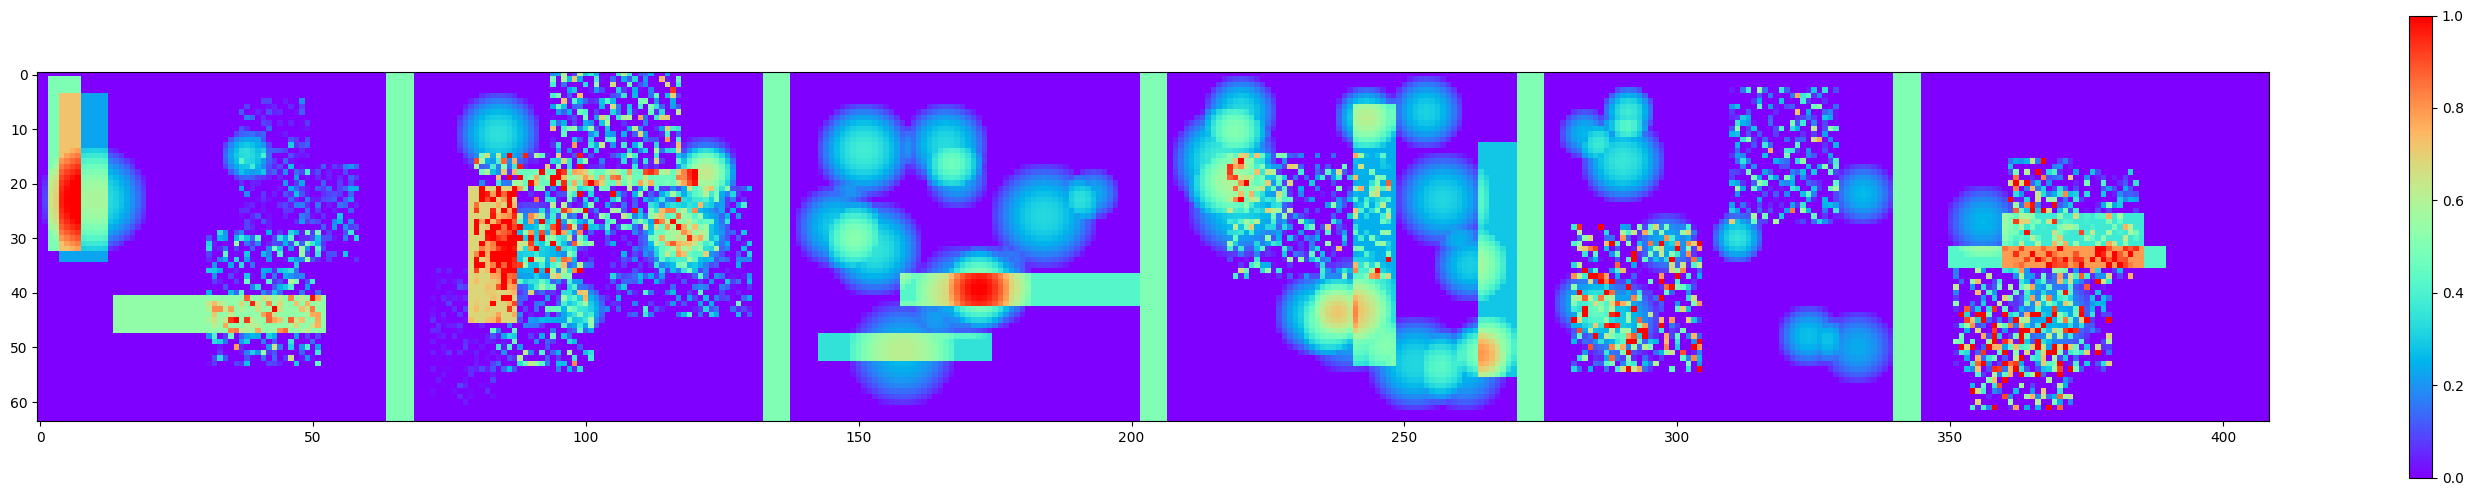

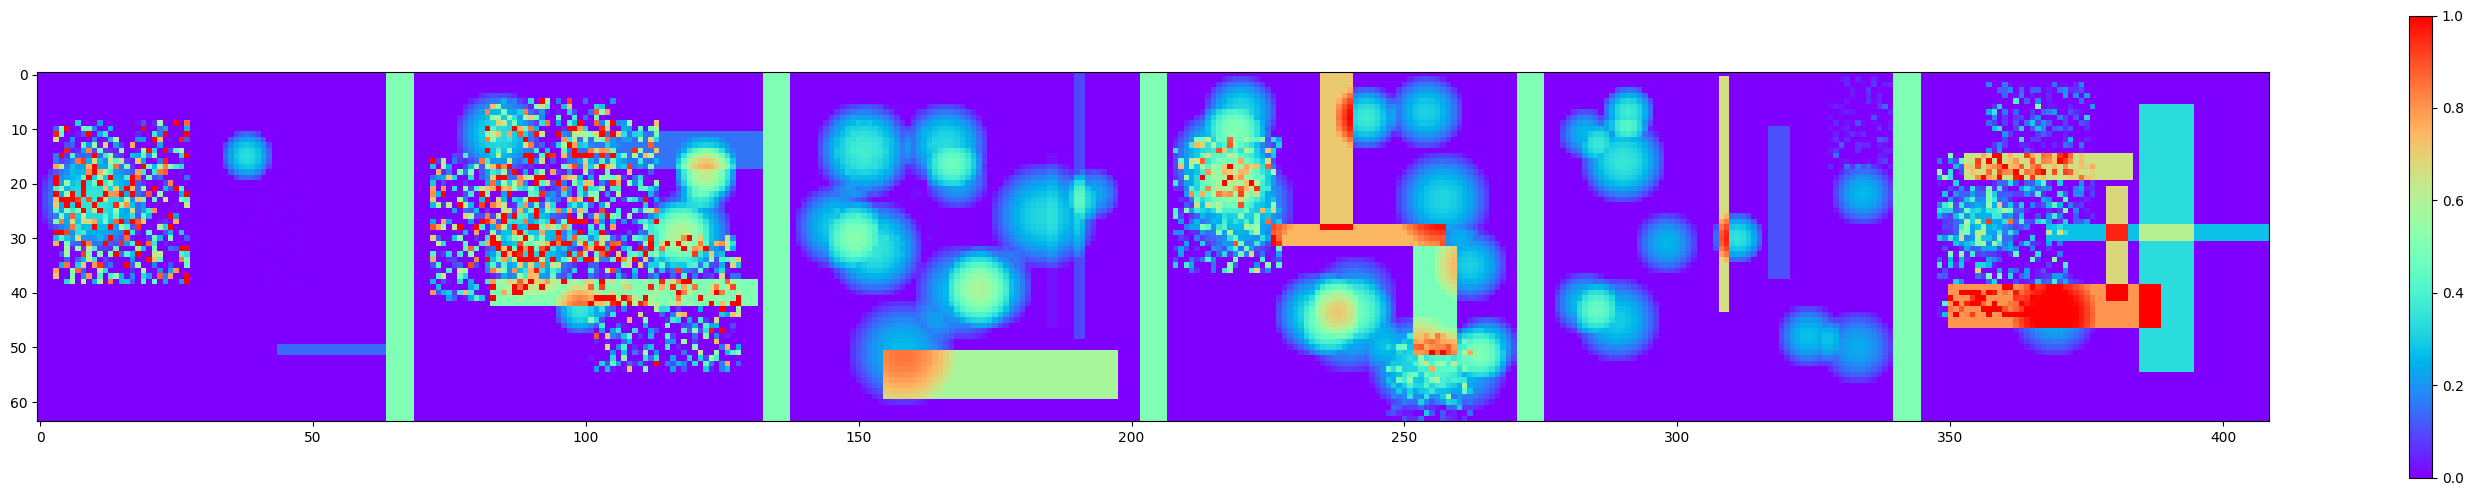

In [3]:
image1, image2 = gen_noise2noise(6)
fig = plt.figure(0, figsize=(36, 6))
voir_batch2D(image1, 6, fig, k=0, min_scale=0,max_scale=1)

fig2 = plt.figure(1, figsize=(36, 6))
voir_batch2D(image2.detach().cpu(), 6, fig2, k=0, min_scale=0,max_scale=1)

**Q1:** Define a learning procedure that effectively denoises the image.

In [4]:
fcn = UNet(1,1,16).cuda()

import torch.optim as optim
optimizer = optim.Adam(fcn.parameters(), 10**(-3))

In [5]:
nepochs = 40
nbatches = 100
batchsize = 64

train_losses = []


def criterion(output,target):
  return torch.mean(torch.abs(output-target))  # idea: use the MAE loss to target the conditionnal median

for epoch in range(nepochs):


    print("Epoch " + str(epoch))
    epoch_losses  = []
    for i in range(nbatches):
        #Load inputs

        # Generation
        input,target = gen_noise2noise(batchsize)

        # go to GPU
        input = input.cuda()
        target = target.cuda()

        # zeroing gradients, forward pass
        optimizer.zero_grad()
        output = fcn(input)

        # loss and compuation of gradients
        loss = criterion(output,target)
        loss.backward()

        # Update weights
        optimizer.step()

        epoch_losses.append(loss.detach().cpu())

        del target, input, loss
        torch.cuda.empty_cache()

    epoch_loss = np.mean(epoch_losses)
    train_losses.append(epoch_loss)
    print('epoch loss : \n')
    print(epoch_loss)

Epoch 0
epoch loss : 

0.123774596
Epoch 1
epoch loss : 

0.09045232
Epoch 2
epoch loss : 

0.08720193
Epoch 3
epoch loss : 

0.087037265
Epoch 4
epoch loss : 

0.08438997
Epoch 5
epoch loss : 

0.08404784
Epoch 6
epoch loss : 

0.08318861
Epoch 7
epoch loss : 

0.083491124
Epoch 8
epoch loss : 

0.08246987
Epoch 9
epoch loss : 

0.0835749
Epoch 10
epoch loss : 

0.082128085
Epoch 11
epoch loss : 

0.08240615
Epoch 12
epoch loss : 

0.08173242
Epoch 13
epoch loss : 

0.08232073
Epoch 14
epoch loss : 

0.082307294
Epoch 15
epoch loss : 

0.08123647
Epoch 16
epoch loss : 

0.08097379
Epoch 17
epoch loss : 

0.08137731
Epoch 18
epoch loss : 

0.08235114
Epoch 19
epoch loss : 

0.0810507
Epoch 20
epoch loss : 

0.08109243
Epoch 21
epoch loss : 

0.07972167
Epoch 22
epoch loss : 

0.08004472
Epoch 23
epoch loss : 

0.08115469
Epoch 24
epoch loss : 

0.07973289
Epoch 25
epoch loss : 

0.07920926
Epoch 26
epoch loss : 

0.08096198
Epoch 27
epoch loss : 

0.08022924
Epoch 28
epoch loss : 

0.0

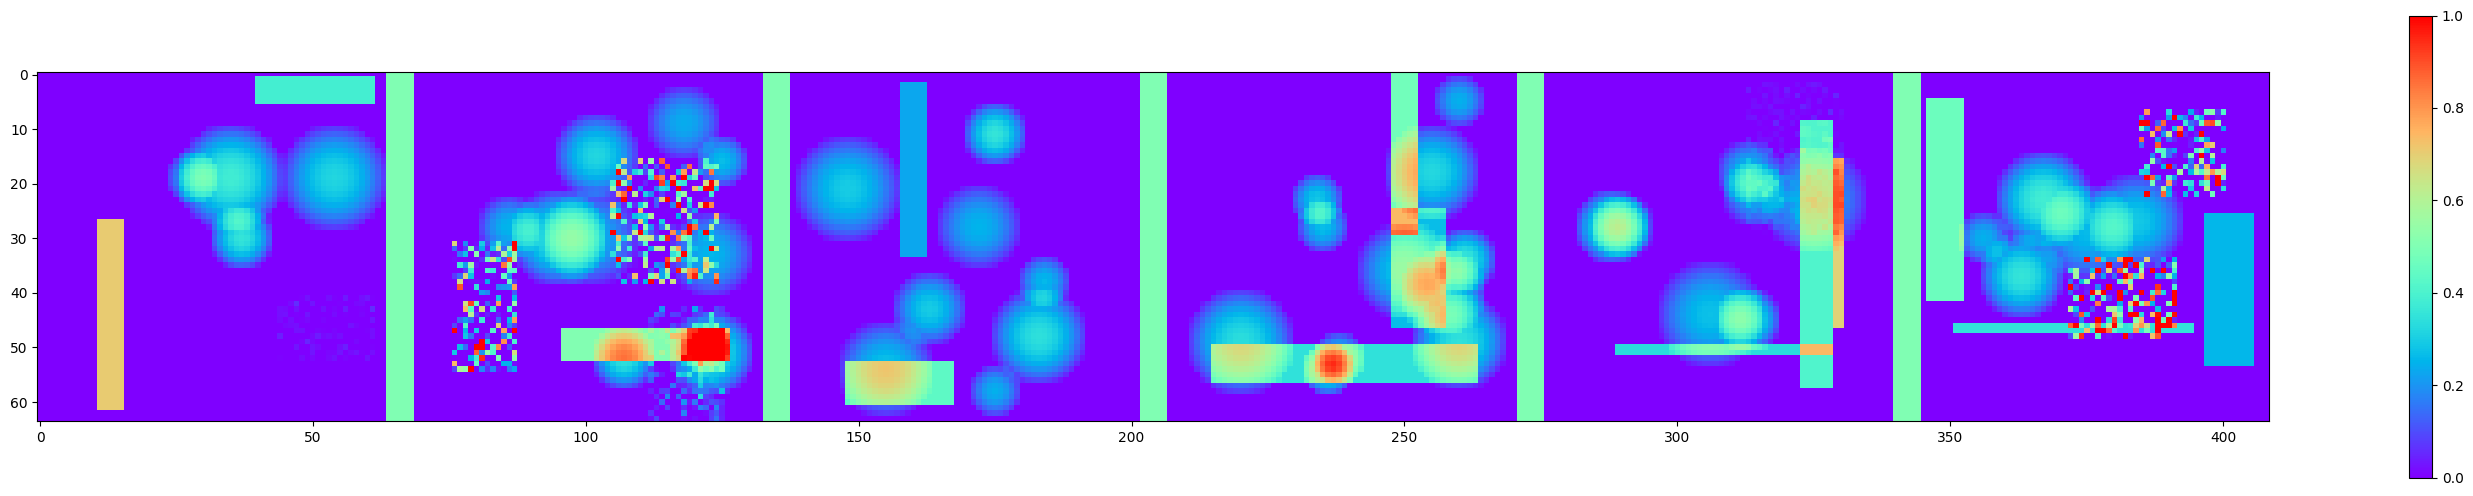

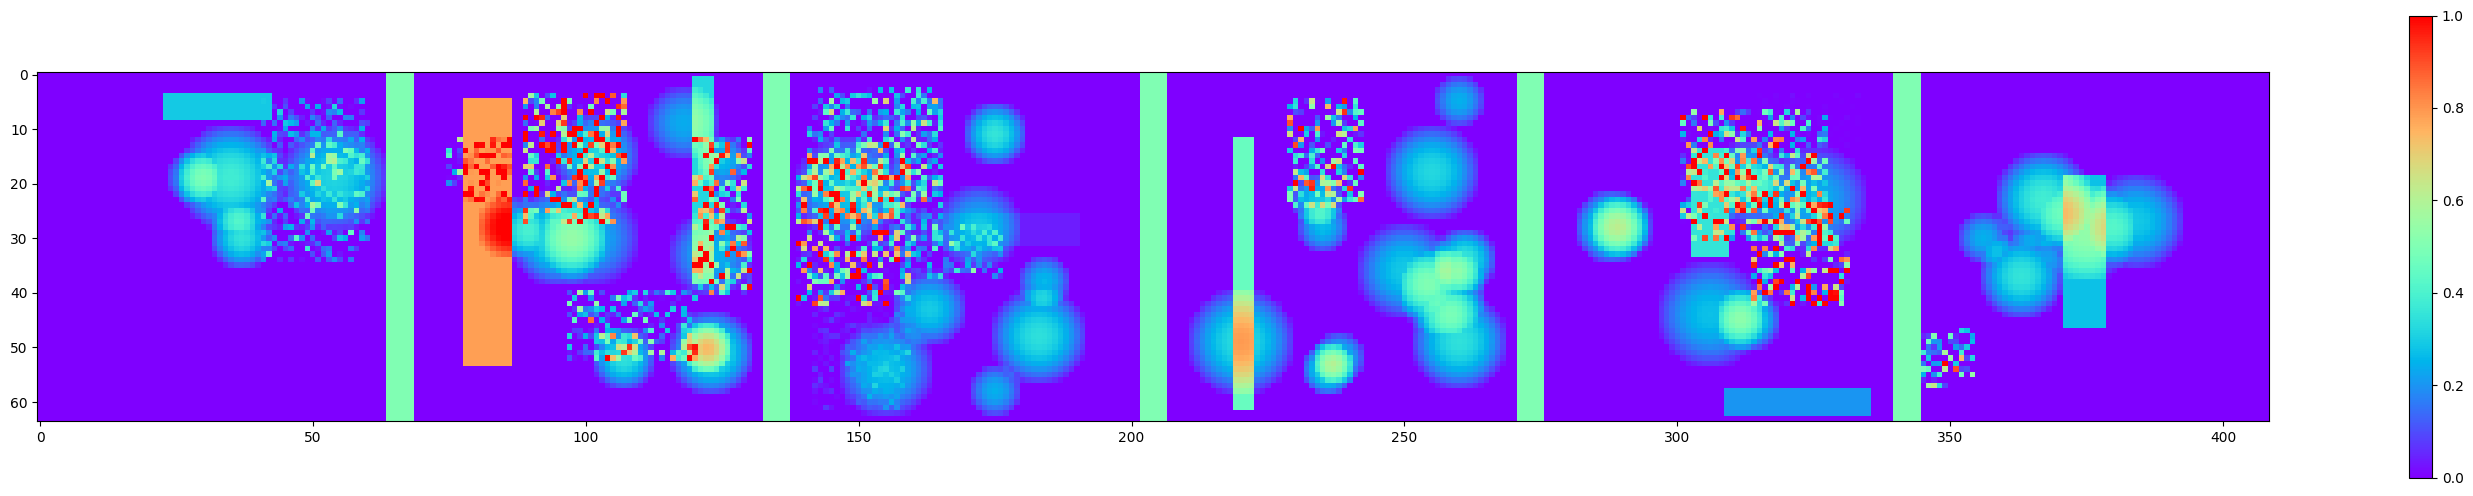

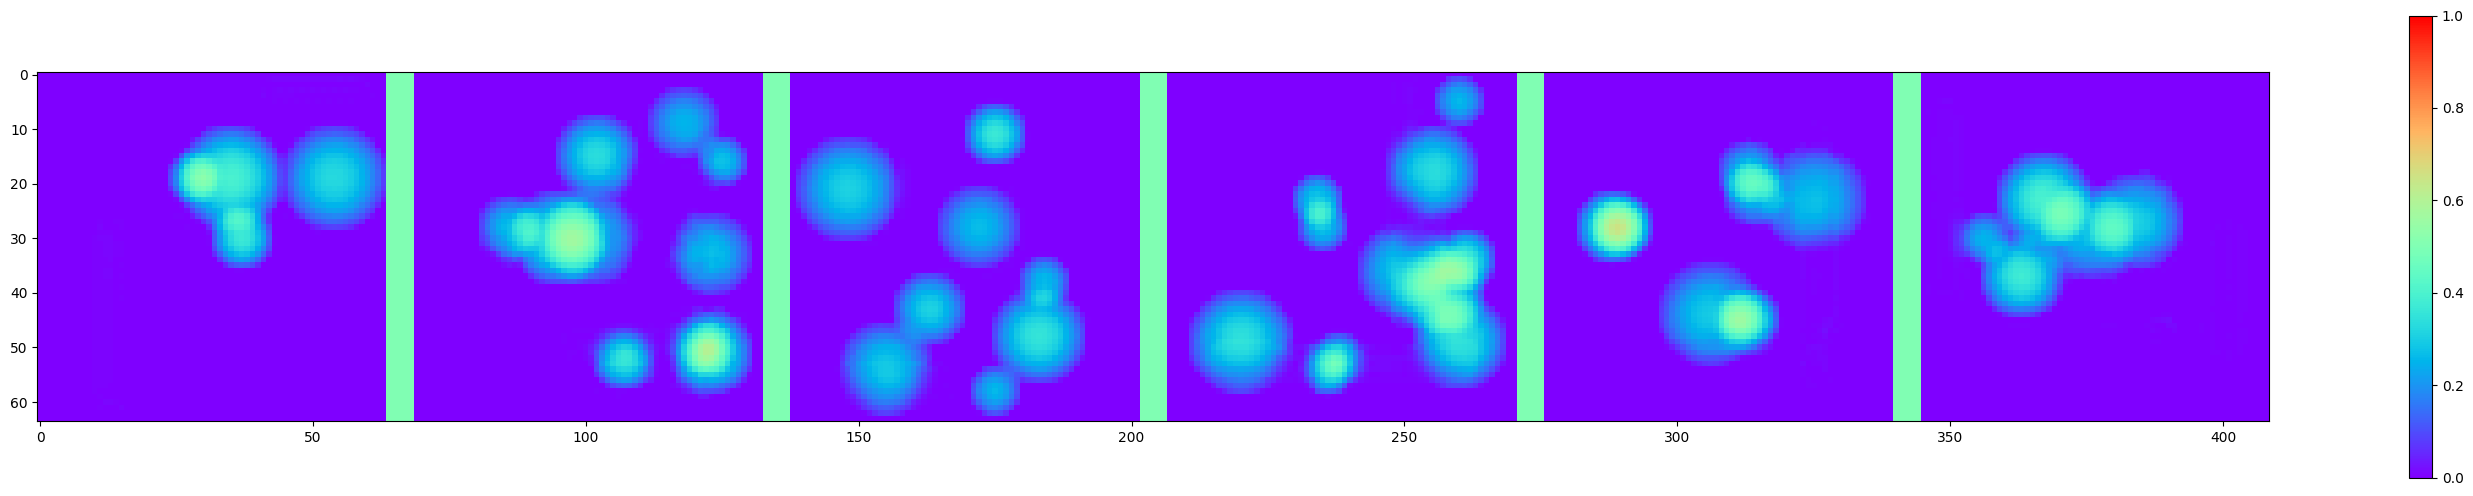

In [6]:
# viz:
fcn.eval()

input, target = gen_noise2noise(6)

output = fcn(input.cuda())

fig = plt.figure(0, figsize=(36, 6))
voir_batch2D(input, 6, fig, k=0, min_scale=0,max_scale=1)  # inputs
fig2 = plt.figure(1, figsize=(36, 6))
voir_batch2D(target, 6, fig2, k=0, min_scale=0,max_scale=1)  # targets
fig3 = plt.figure(2, figsize=(36, 6))
voir_batch2D(output.detach().cpu(), 6, fig2, k=0, min_scale=0,max_scale=1) # outputs


**Q2:** Theoretical analysis:

The training procedure involves searching for the weights $\theta^*$ that satisfy:

\begin{equation}
\theta^* = \underset{\theta}{argmin} {\big \{} \mathbb{E}_{(X,Y)}[ \ \mathcal{L} (f_\theta(X), Y) \ ] {\big \}} \tag{1}
\end{equation}

Rewrite $\mathbb{E}_{(X,Y)}[ \mathcal{L} (f_\theta(X), Y) ]$ to justify the approach taken for **Q1**.



**Justification of the Noise-to-Noise Approach:**

Let's denote:
- $X_1$ and $X_2$: two independent noisy versions of an unknown clean image $C$
- $f_\theta$: the denoising network with parameters $\theta$

In the noise-to-noise scenario, we have pairs $(X_1, X_2)$ where both are independent noisy observations. We want to minimize:

$$\mathbb{E}_{(X_1,X_2)}[ \mathcal{L} (f_\theta(X_1), X_2) ]$$

**Key insight:** If the noise components in $X_1$ and $X_2$ are independent, we can decompose:
- $X_1 = C + N_1$
- $X_2 = C + N_2$

where $N_1$ and $N_2$ are independent noise sources.

When training $f_\theta(X_1) \approx X_2$, the network learns to:
1. Remove the noise $N_1$ from $X_1$
2. Since $\mathbb{E}[N_1] = \mathbb{E}[N_2] = 0$ and they are independent, the network learns to recover the clean signal $C$

This works because the network cannot fit the independent noise (it has no correlation to exploit), so it learns to preserve only the signal common to both $X_1$ and $X_2$, which is the clean image $C$.

**Mathematical justification:**
$$\mathbb{E}_{(X_1,X_2)}[ \mathcal{L} (f_\theta(X_1), X_2) ] = \mathbb{E}_{C,N_1,N_2}[ \mathcal{L} (f_\theta(C+N_1), C+N_2) ]$$

By minimizing over independent noise, the optimal solution is approximately: $f_\theta(C+N_1) \approx C$

###**Exercise 2: The "NES" scenario (Neural Egg Separation)**

In another scenario, two sources of images can be sampled independently. The first provides noisy images containing the object of interest. Images from the second source contain only noise. Additionally, the corruption process, i.e., how the noise is combined with the clean image, is assumed to be known. This is a relatively common scenario. For instance, in the case of meteorological radar images, it is possible to extract images containing only noise during non-precipitation periods.

This scenario was defined by [Halperin et al (2018)](https://arxiv.org/pdf/1811.12739.pdf). These authors propose an iterative method to address it (Neural Egg Separation). In this exercise, we will rely on a fairly similar principle, still using our synthetic images.

The functions gen1_NES and gen2_NES allow sampling from the two sources. The corruption process is trivial: the noise (rectangles) is simply added to the clean image (cells).   



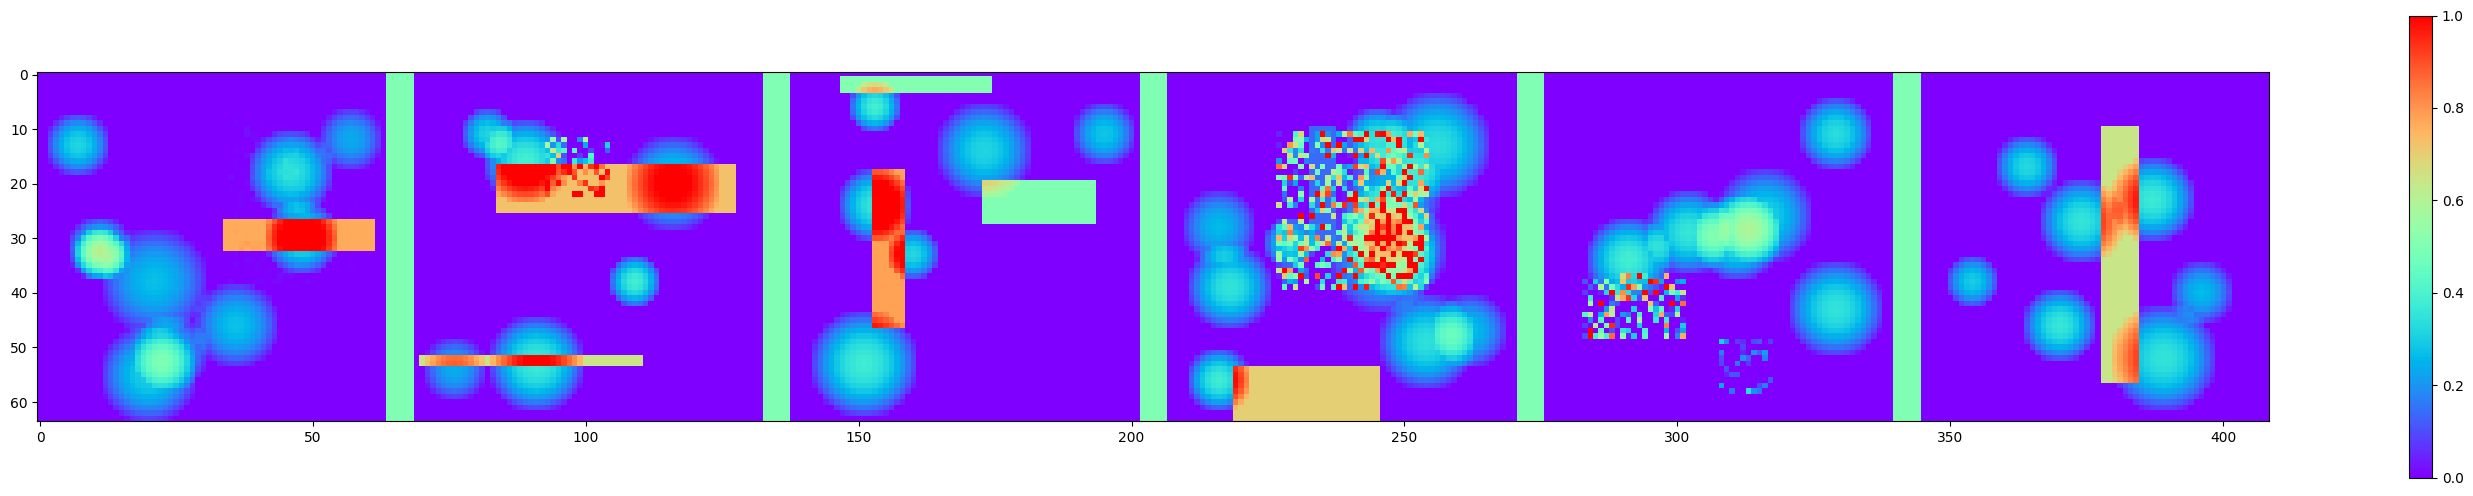

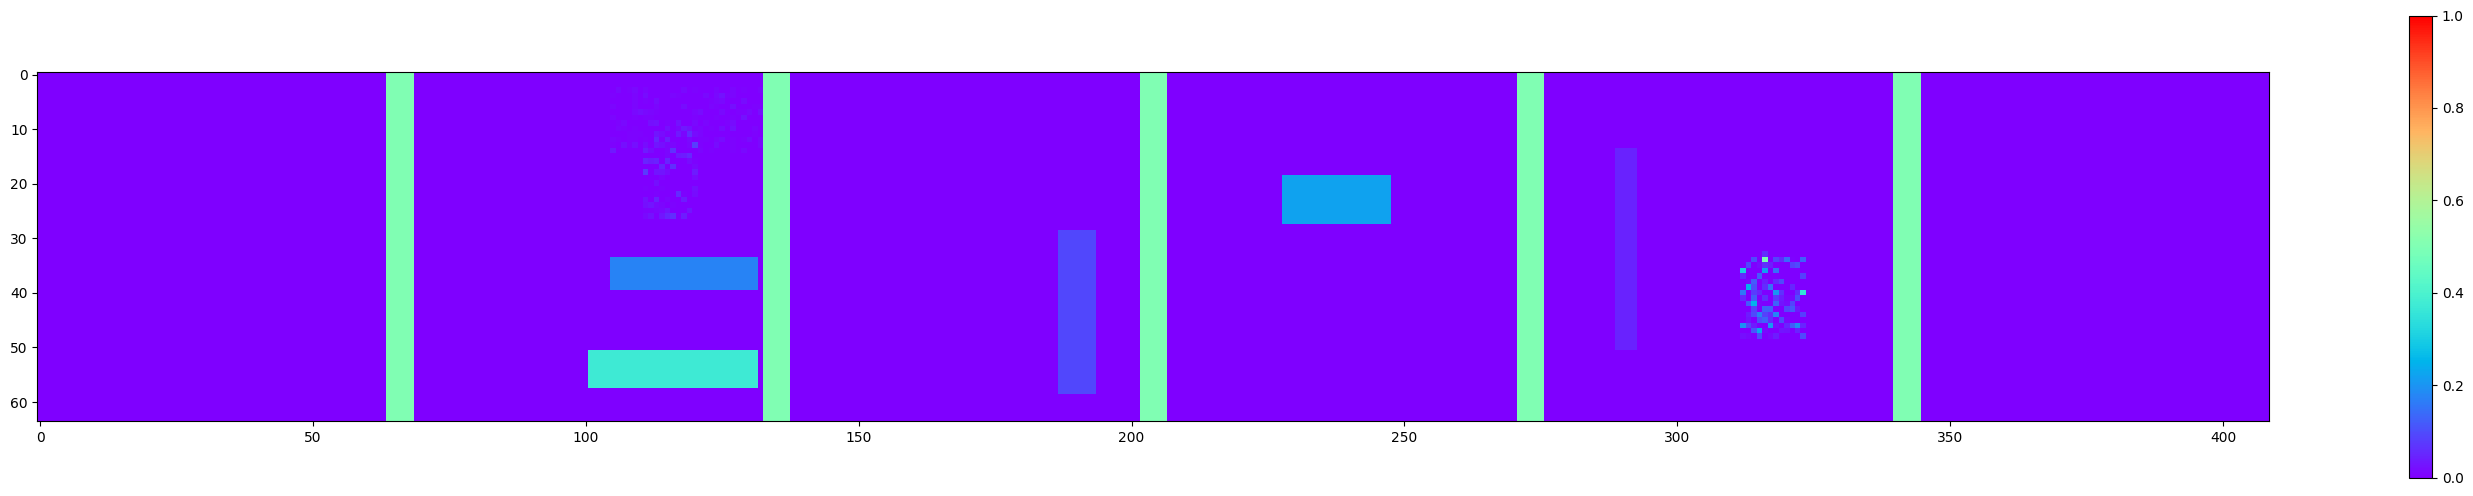

: 

In [ ]:
from utile import gen1_NES, gen2_NES

image1 = gen1_NES(6)
noise = gen2_NES(6)

# sample noisy pictures:
fig = plt.figure(0, figsize=(36, 6))
voir_batch2D(image1, 6, fig, k=0, min_scale=0,max_scale=1)

# sample noise:
fig2 = plt.figure(1, figsize=(36, 6))
voir_batch2D(noise, 6, fig2, k=0, min_scale=0,max_scale=1)

**Q1:** Propose a learning strategy that leads to effective denoising.

**Q2:** Discuss the limitations of the method and mention some avenues for improvement.

### 1°) Proposed Learning Strategy for Neural Egg Separation (NES)

**Problem Setup:**
- Source 1: Noisy images with objects (object + noise)
- Source 2: Pure noise samples
- Corruption model: Additive (image = clean_object + noise)

**Learning Strategy:**

**Key Insight:** If we have access to pure noise samples, we can leverage this to learn a denoiser directly.

The optimal strategy is:
1. **Train the network** to map: noisy_images → clean_images
2. **Use the noise samples** to regularize the learning process
3. **Loss function:**
   $$\mathcal{L}(\theta) = \mathbb{E}_{I_{noisy}}[ \|f_\theta(I_{noisy}) - \text{clean}_I\|^2 ] + \lambda \mathbb{E}_{n \sim \text{noise}}[ \|f_\theta(f_\theta(n))\|^2 ]$$
   
   Where the second term encourages the network to suppress pure noise (applying the network twice on noise should give near-zero output).

**Implementation approach:**
- Use source 1 (noisy images with objects) as input
- Use the residual (noise) estimate from a pre-trained or auxiliary network as target
- Alternatively: Train the network so that $f_\theta(\text{image}) - \text{image}$ estimates the noise, and then refine using the noise samples from source 2

**Advantage:** We can exploit the fact that noise samples are available to learn what noise looks like, improving the separation between signal and noise.

### 2°) Limitations and Improvements of the NES Method

**Limitations:**

1. **Additive Noise Assumption:**
   - The method assumes noise is additive: $I = C + N$
   - Real-world noise is often multiplicative, signal-dependent, or non-linear
   - Fails for Poisson noise, sensor noise, or artifact-based corruption

2. **Distribution Mismatch:**
   - Pure noise samples (source 2) may not have the same distribution as actual noise in noisy images (source 1)
   - Domain shift can severely degrade performance

3. **Correlated Noise:**
   - If noise in the two sources is correlated or depends on the signal, the assumption breaks down
   - Example: Compression artifacts that depend on image content

4. **Limited Information:**
   - The network sees only corrupted images and pure noise, not the clean signal directly
   - Can lead to suboptimal separation when signal and noise have overlapping frequency contents

5. **Scalability Issues:**
   - Requires representative noise samples, which may be unavailable or incomplete
   - Difficult to adapt to different noise types without retraining

**Avenues for Improvement:**

1. **Adversarial Training:**
   - Use a discriminator to determine if the output is "clean" vs "containing artifacts"
   - Encourages more realistic denoising

2. **Unsupervised Learning with Priors:**
   - Incorporate image restoration priors (smoothness, sparsity in frequency domain)
   - Use variational methods or score-based models

3. **Self-Supervised Learning:**
   - Learn from the noisy images themselves using rotation invariance, inpainting, or other self-consistency losses
   - No need for external noise samples

4. **Blind Deconvolution Techniques:**
   - Jointly estimate the noise corruption model and the clean image
   - More robust when corruption assumptions may not hold exactly

5. **Deep Prior Methods:**
   - Use the implicit bias of deep networks to prefer natural images over noise
   - Train only on the noisy image without external supervised data

6. **Domain Adaptation:**
   - Use techniques to align the distribution of noise samples with actual noise in corrupted images
   - Transfer learning from synthetic to real noise